#PROBLEM STATEMENT:

Recruitment companies and organizations often face challenges in determining an appropriate salary for a job position. Salary depends on several factors such as job role, experience level, required skills, company size, location, industry, employment type, remote work, and benefits.

The objective of this project is to develop a Machine Learning regression model that predicts the expected salary of a job in USD based on its job-related, company-related, and candidate-related attributes. The project will analyze historical job data to identify salary patterns and use KNN Regression to estimate the salary of new job positions based on similar jobs in the dataset.

In [1]:
import numpy as np
import pandas as pd

In [2]:
import sklearn
print(sklearn.__version__)

1.9.1


In [3]:
!pip install -U scikit-learn==1.9.1

In [4]:
import sklearn
print(sklearn.__version__)

1.9.1


In [5]:
df=pd.read_csv("/content/ai_job_dataset.csv")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [7]:
df['posting_date'] = pd.to_datetime(df['posting_date'])
df['application_deadline'] = pd.to_datetime(df['application_deadline'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   job_id                  15000 non-null  object        
 1   job_title               15000 non-null  object        
 2   salary_usd              15000 non-null  int64         
 3   salary_currency         15000 non-null  object        
 4   experience_level        15000 non-null  object        
 5   employment_type         15000 non-null  object        
 6   company_location        15000 non-null  object        
 7   company_size            15000 non-null  object        
 8   employee_residence      15000 non-null  object        
 9   remote_ratio            15000 non-null  int64         
 10  required_skills         15000 non-null  object        
 11  education_required      15000 non-null  object        
 12  years_experience        15000 non-null  int64 

numerical columns:
salary_usd,remote_ratio,years_Exp,job_description_length,benefits_score

-categorical columns:
-job_title
experience_level
employment_type
company_location
company_size
company_name
employee_residence
education_required
required_skills
industry
salary_currency
job_id
  

-date columns
-posting_date
application_deadline


In [9]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [10]:
df.isnull().sum()

,0
job_id,0
job_title,0
salary_usd,0
salary_currency,0
experience_level,0
employment_type,0
company_location,0
company_size,0
employee_residence,0
remote_ratio,0


zero missing values

In [11]:
df.duplicated().sum()

np.int64(0)

zero duplicate values

In [12]:
df.describe()

,salary_usd,remote_ratio,years_experience,posting_date,application_deadline,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000,15000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,2024-08-29 08:48:51.840000,2024-10-11 21:55:23.520000,1503.314733,7.504273
min,32519.000000,0.000000,0.000000,2024-01-01 00:00:00,2024-01-16 00:00:00,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,2024-04-29 00:00:00,2024-06-13 00:00:00,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,2024-08-28 00:00:00,2024-10-12 00:00:00,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2024-12-29 00:00:00,2025-02-10 00:00:00,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2025-04-30 00:00:00,2025-07-11 00:00:00,2499.000000,10.000000
std,60260.940438,40.812712,5.545768,NaN,NaN,576.127083,1.450870


we need visualization bcz to understand-

-Distribution → Where are most values concentrated?
Example: Are most salaries ₹3–8 LPA or ₹10–20 LPA?

Skewness → Is the data balanced or pulled toward one side?
Example: Most salaries are low, but a few are extremely high.
Outliers → Are there unusual values?
Example: Most experience is 1–10 years, but one person has 40 years.

Relationships → Are two variables related?
Example: Does salary increase as experience increases?

Category differences → Which categories have higher/lower values?
Example: Do different job roles have different salary levels?

Spread/range → How much do values vary?
Example: Experience ranges from 0–20 years, while salary ranges from ₹2–50 LPA.

In one simple sentence:

We use visualization in EDA to see patterns, distributions, relationships, unusual values, and differences in our data that may not be easy to understand just by looking at raw numbers.

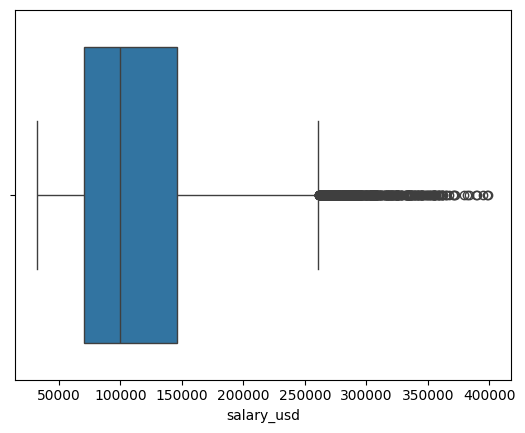

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(df,x="salary_usd")
plt.show()

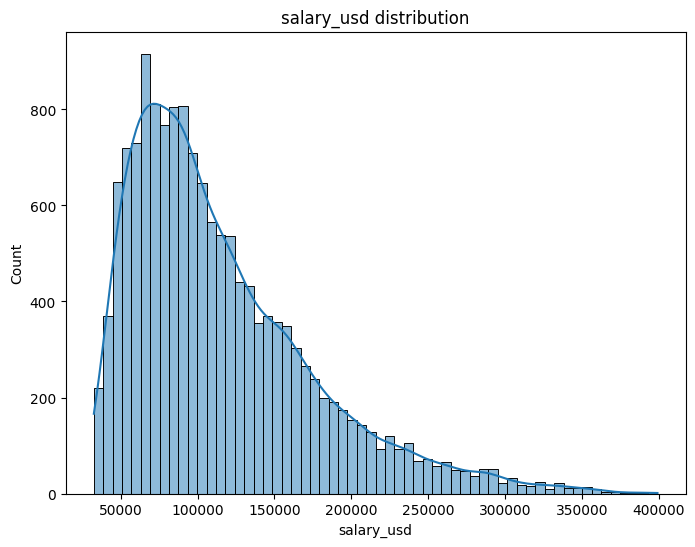

In [14]:
plt.figure(figsize=(8,6))
sns.histplot(df,x="salary_usd",kde=True)
plt.title("salary_usd distribution")
plt.show()

salary_usd is positively (right) skewed, indicating that most job salaries are concentrated in the lower-to-middle salary range, while a smaller number of high-paying jobs extend the distribution toward higher salary values.

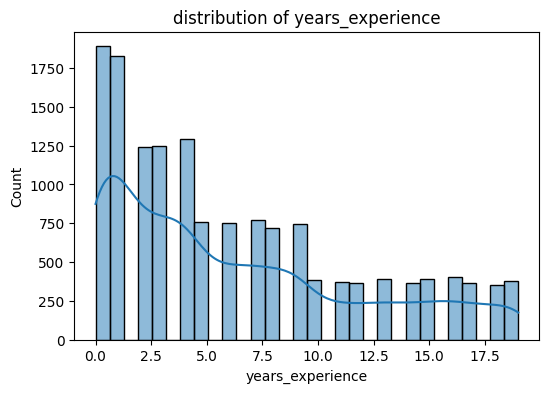

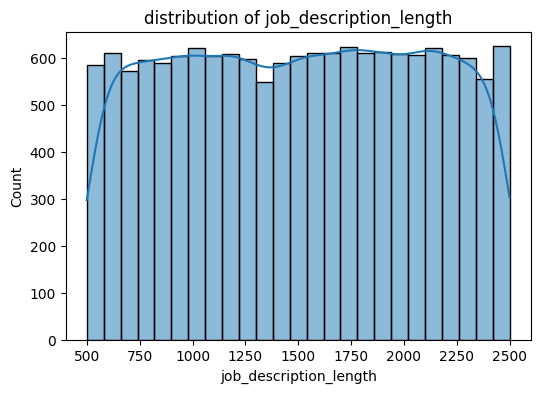

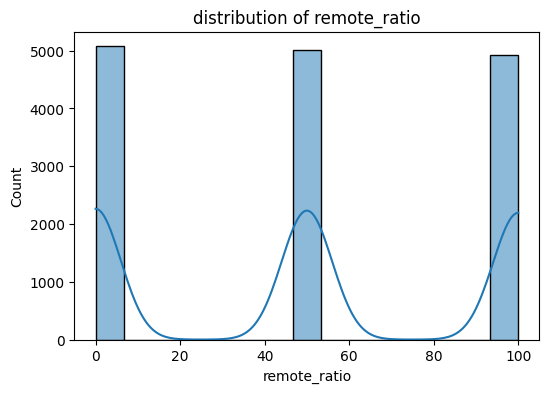

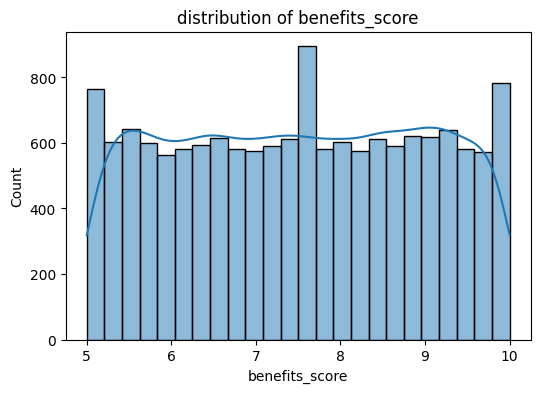

In [15]:
numeric_cols=[
    "years_experience",
    "job_description_length",
    "remote_ratio",
    "benefits_score"
]
for col in numeric_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col],kde=True)
  plt.title(f'distribution of {col}')
  plt.show()

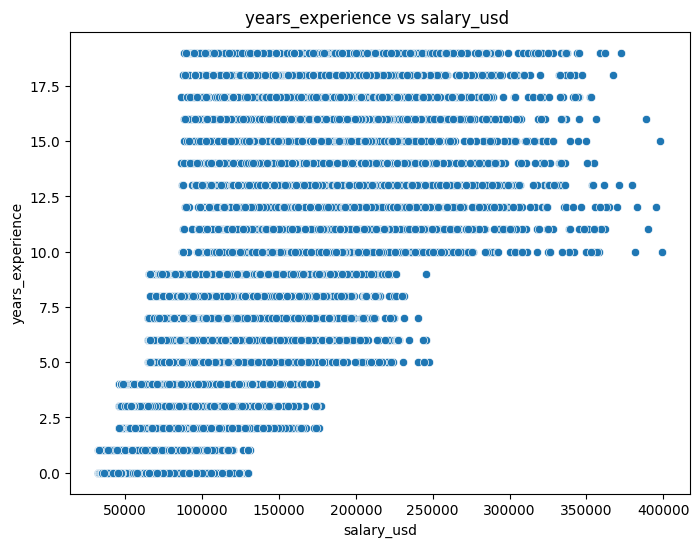

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(df,
                x="salary_usd",
                y="years_experience")
plt.title("years_experience vs salary_usd ")
plt.show()

high experince high salary

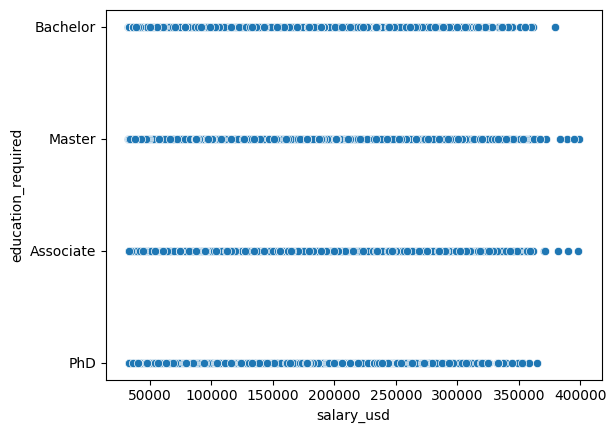

In [17]:
sns.scatterplot(df,x="salary_usd",y="education_required")
plt.show()

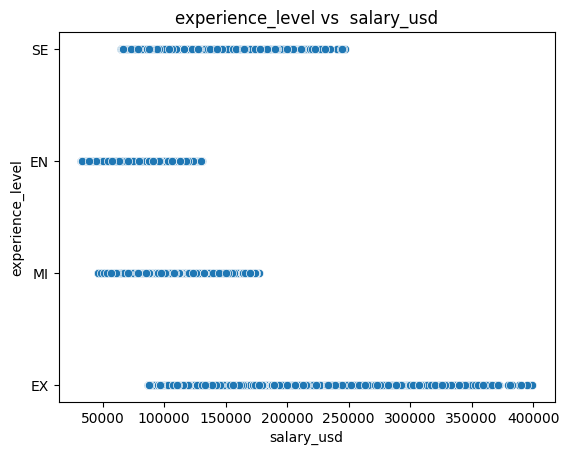

In [18]:
sns.scatterplot(df,x="salary_usd",y="experience_level")
plt.title("experience_level vs  salary_usd")
plt.show()

salary is differed between entry,mid-level,senior,executive level

-executive have high salary

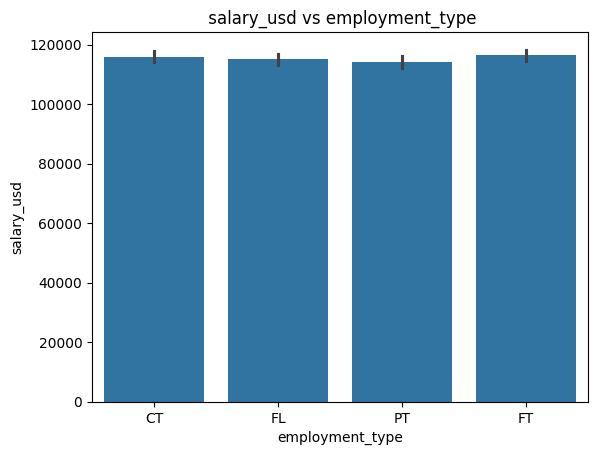

In [19]:
sns.barplot(df,x="employment_type",y="salary_usd")
plt.title(" salary_usd vs employment_type")
plt.show()

all employment_type has same salary

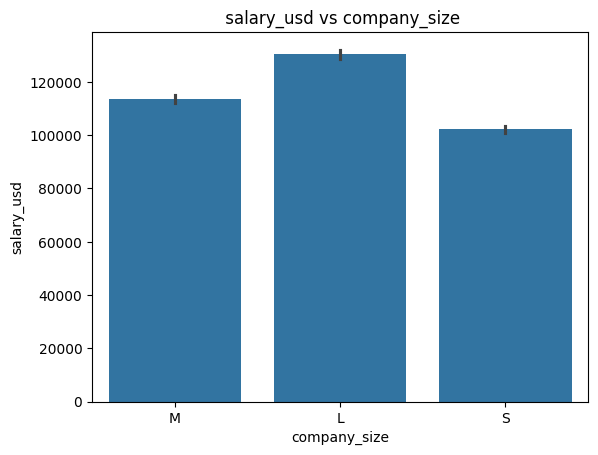

In [20]:
sns.barplot(df,x="company_size",y="salary_usd")
plt.title(" salary_usd vs company_size")
plt.show()

large company size has high salaries

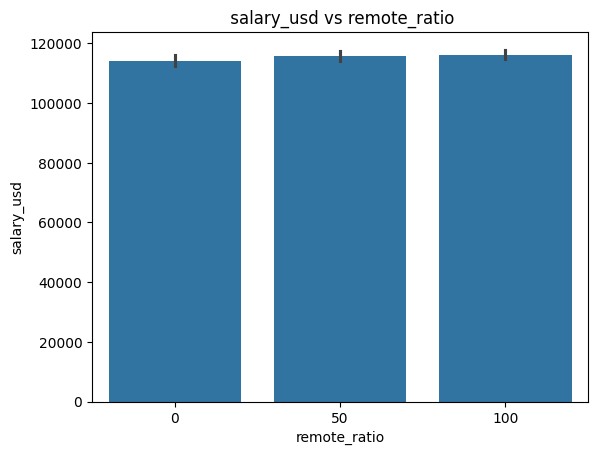

In [21]:
sns.barplot(df,x="remote_ratio",y="salary_usd")
plt.title(" salary_usd vs remote_ratio")
plt.show()

there is no differece between range 0 -100 remote ratio

-same salaries

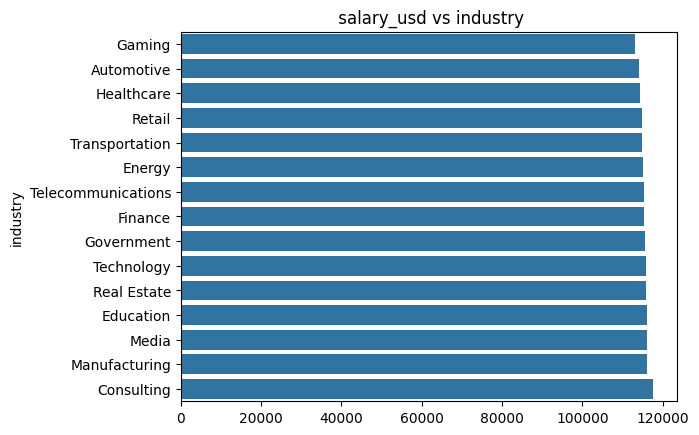

In [22]:
industry_salary=df.groupby("industry")["salary_usd"].mean().sort_values()
sns.barplot(x=industry_salary.values,y=industry_salary.index)
plt.title(" salary_usd vs industry")
plt.show()

consulting has small difference of salary compared to others

- it has high salary

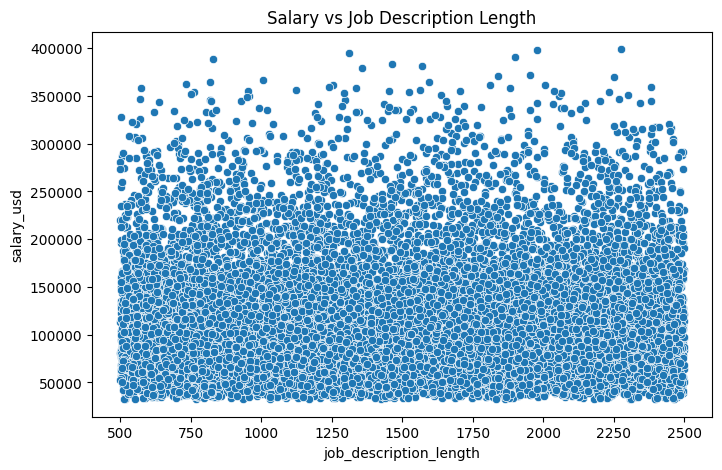

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(df,x="job_description_length",y="salary_usd")
plt.title("Salary vs Job Description Length")
plt.show()

-so there is no much difference between salary vs job description length

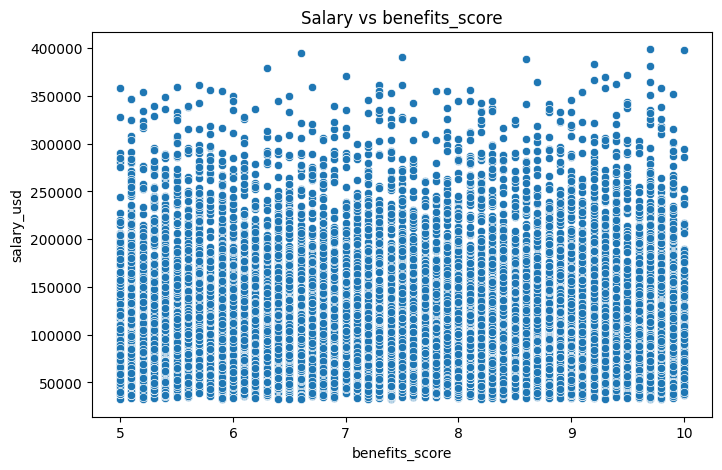

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(df,x="benefits_score",y="salary_usd")
plt.title("Salary vs benefits_score")
plt.show()

- no relationship between salary and benefit_Score

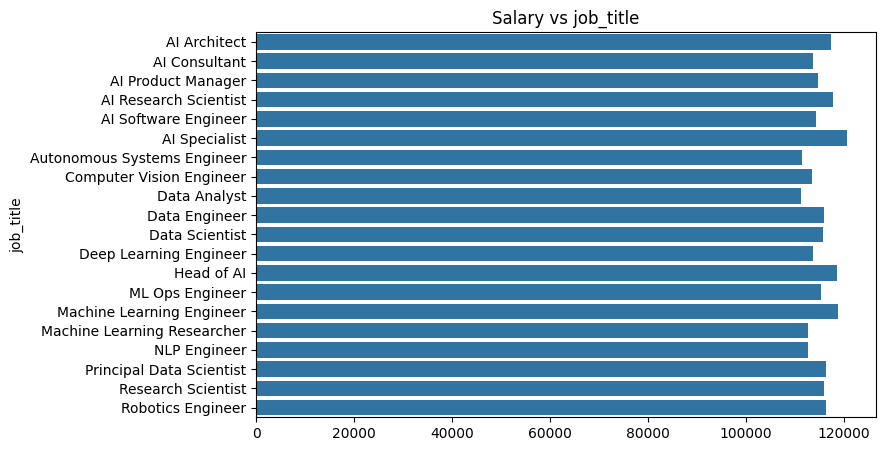

In [25]:
job_salary=(df.groupby("job_title")["salary_usd"].mean())
plt.figure(figsize=(8,5))
sns.barplot(x=job_salary.values,y=job_salary.index)
plt.title("Salary vs job_title")
plt.show()

-Ai specialist has high salary compared to other job_titles

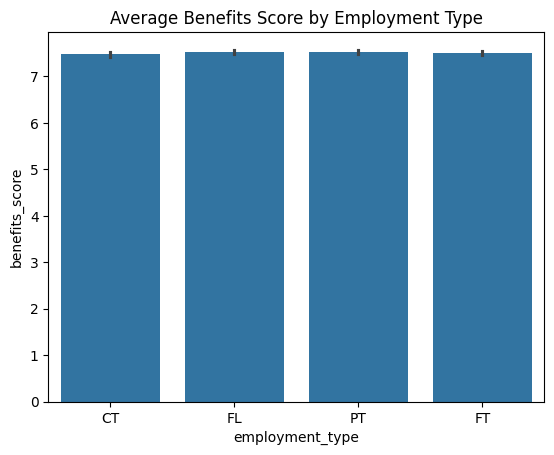

In [26]:
sns.barplot(df,
    x='employment_type',
    y='benefits_score')

plt.title('Average Benefits Score by Employment Type')
plt.show()

-almost all employment_type has equal benefit score

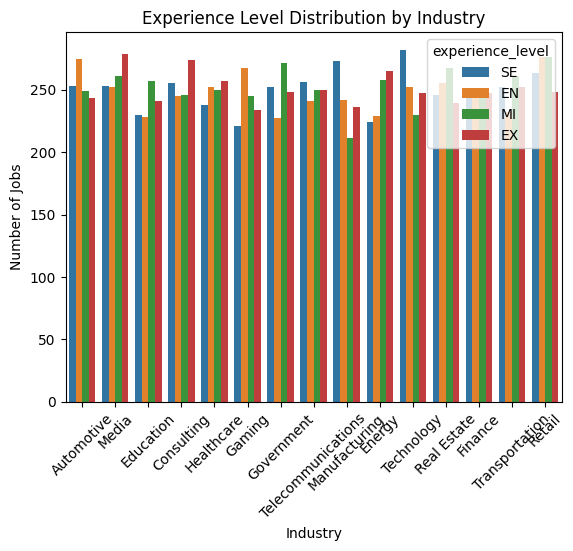

In [27]:
sns.countplot(df,x="industry",hue="experience_level")
plt.title('Experience Level Distribution by Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45)
plt.show()

-so each industry has its own seperte experience level

-some industries have more jobs for SE and some have EX

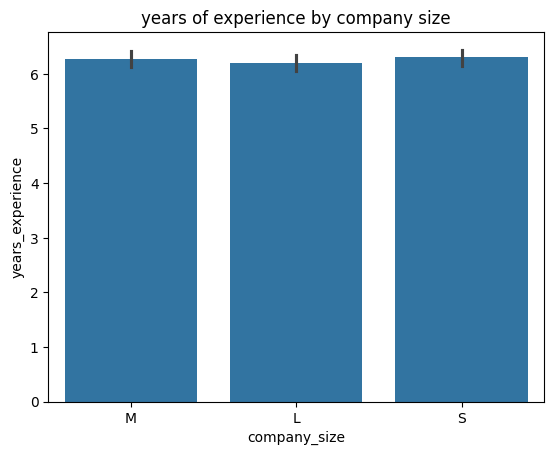

In [28]:
sns.barplot(df,x="company_size",y="years_experience")
plt.title("years of experience by company size")
plt.show()

-there is just slight difference between L company size slightly less has others

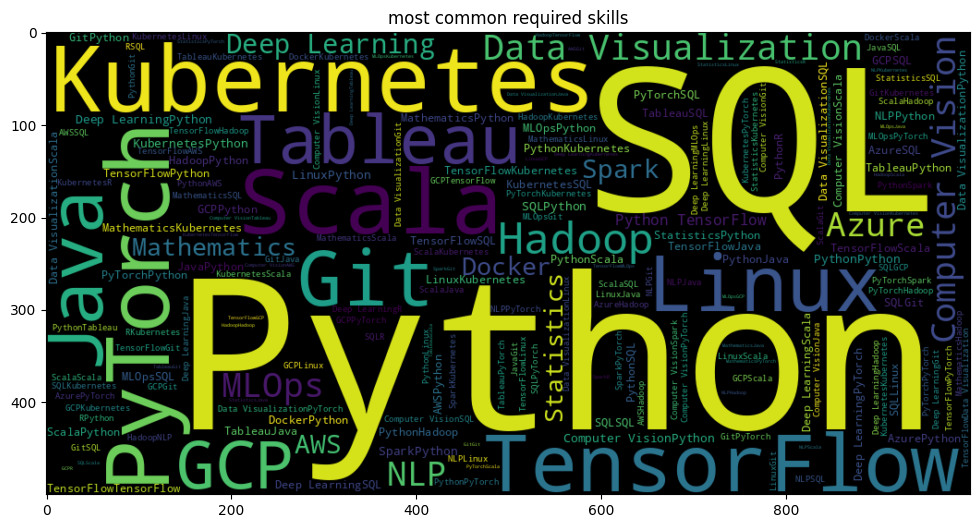

In [29]:
from wordcloud import WordCloud
text="".join(df["required_skills"].dropna().astype(str))
wordcloud=WordCloud( width=1000,
    height=500,).generate(text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud,interpolation="bilinear")
plt.title("most common required skills")
plt.show()

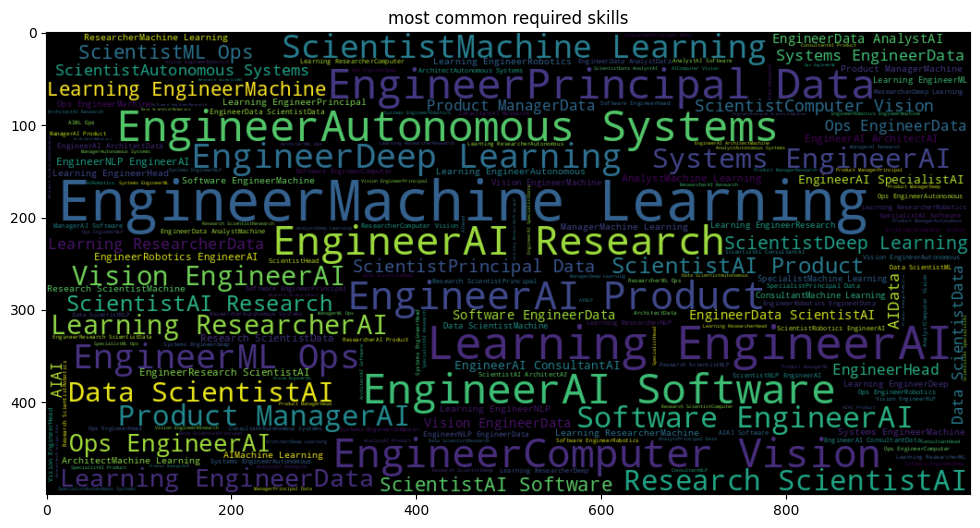

In [30]:
from wordcloud import WordCloud
text="".join(df["job_title"].dropna().astype(str))
wordcloud=WordCloud( width=1000,
    height=500,).generate(text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud,interpolation="bilinear")
plt.title("most common required skills")
plt.show()

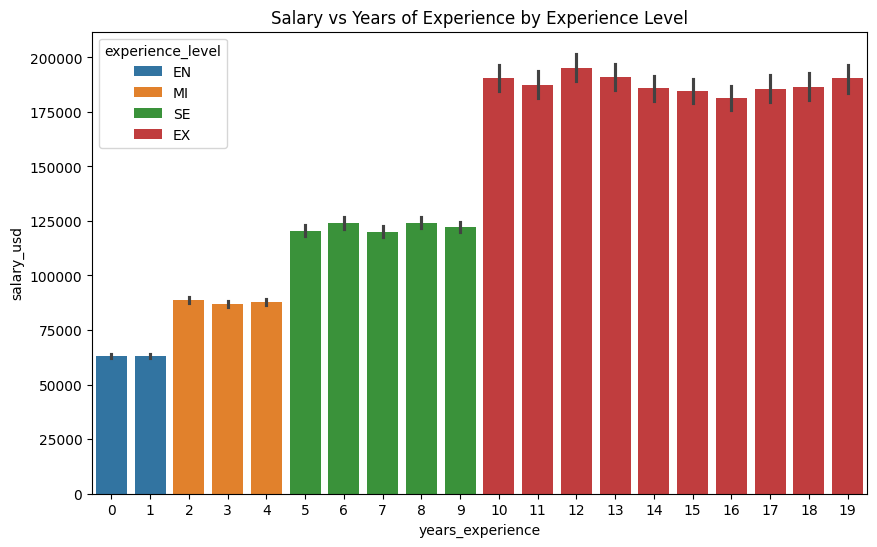

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(df,x="years_experience",y="salary_usd",hue="experience_level")
plt.title("Salary vs Years of Experience by Experience Level")
plt.show()

- ex level and more experience has high salary than others

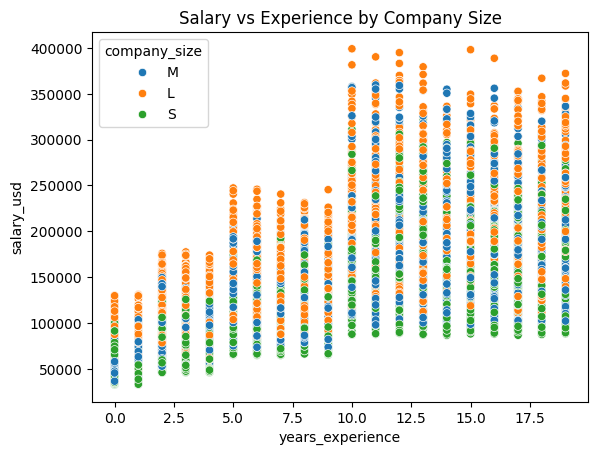

In [32]:
sns.scatterplot(df,x='years_experience',y='salary_usd',hue='company_size'
)
plt.title('Salary vs Experience by Company Size')
plt.show()

-large companysize with less experience less salary and more years_experience high salary

--same for all company size

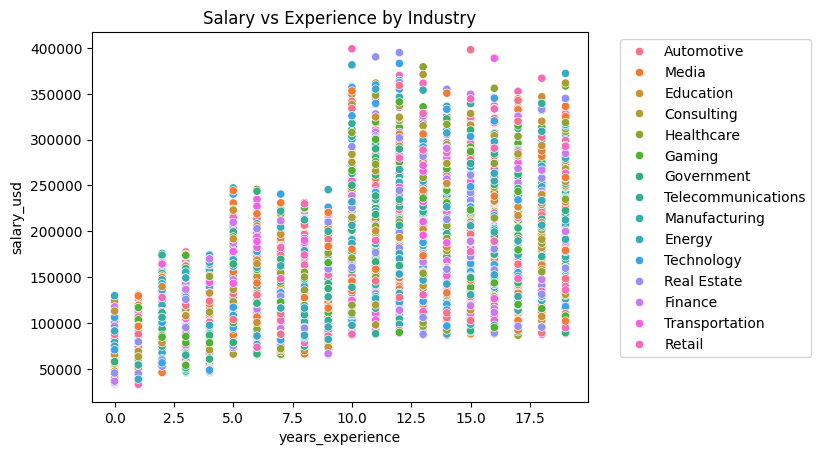

In [33]:
sns.scatterplot(df, x='years_experience',y='salary_usd',
    hue='industry'
)
plt.title('Salary vs Experience by Industry')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

-each industry with high year_experience have high salary

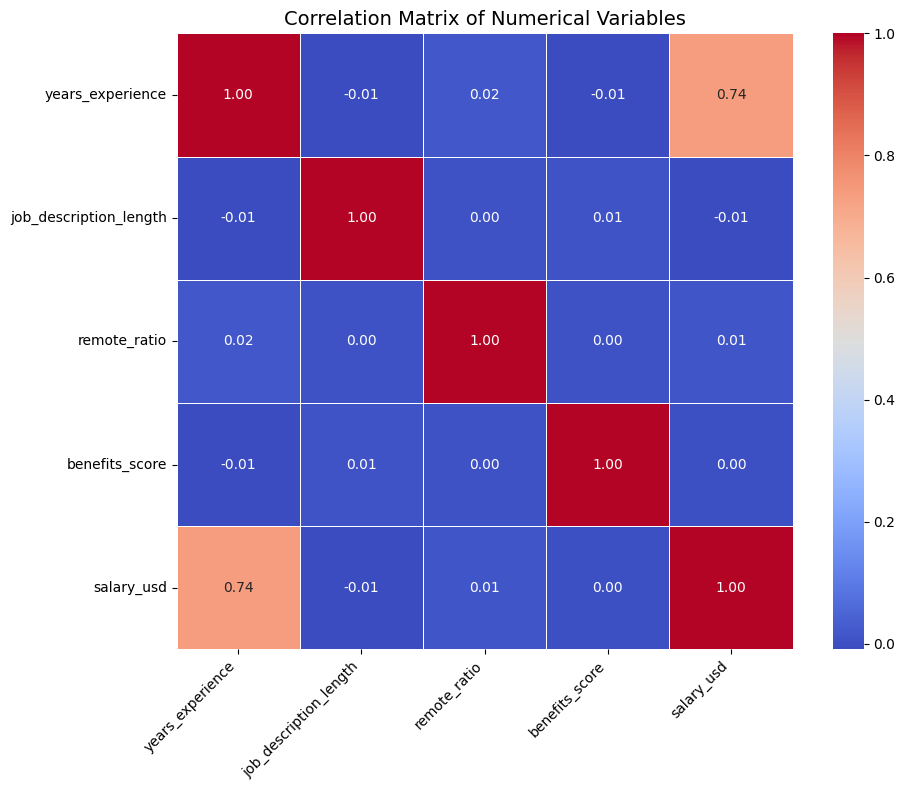

In [34]:
numeric_cols = [
    'years_experience',
    'job_description_length',
    'remote_ratio',
    'benefits_score',
    'salary_usd'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)

plt.title('Correlation Matrix of Numerical Variables', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#FEATURE ENGINEERING

In [35]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   job_id                  15000 non-null  object        
 1   job_title               15000 non-null  object        
 2   salary_usd              15000 non-null  int64         
 3   salary_currency         15000 non-null  object        
 4   experience_level        15000 non-null  object        
 5   employment_type         15000 non-null  object        
 6   company_location        15000 non-null  object        
 7   company_size            15000 non-null  object        
 8   employee_residence      15000 non-null  object        
 9   remote_ratio            15000 non-null  int64         
 10  required_skills         15000 non-null  object        
 11  education_required      15000 non-null  object        
 12  years_experience        15000 non-null  int64 

In [37]:
df['posting_date'] = pd.to_datetime(df['posting_date'])
df['application_deadline'] = pd.to_datetime(df['application_deadline'])

df['posting_year'] = df['posting_date'].dt.year
df['posting_month'] = df['posting_date'].dt.month
df["new_posting_day"]=df["posting_date"].dt.day
df["posting_dayofweek"]=df["posting_date"].dt.dayofweek

In [38]:
df['application_window'] = (
    df['application_deadline'] - df['posting_date']
).dt.days

In [39]:
df["posting_date"]

,posting_date
0,2024-10-18
1,2024-11-20
2,2025-03-18
3,2024-12-23
4,2025-04-15
...,...
14995,2025-02-06
14996,2024-10-16
14997,2024-03-19
14998,2024-03-22


In [40]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,...,posting_date,application_deadline,job_description_length,benefits_score,company_name,posting_year,posting_month,new_posting_day,posting_dayofweek,application_window
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,...,2024-10-18,2024-11-07,1076,5.9,Smart Analytics,2024,10,18,4,20
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,...,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc,2024,11,20,2,52
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,...,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech,2025,3,18,1,20
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,...,2024-12-23,2025-02-24,1345,8.6,Future Systems,2024,12,23,0,63
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,...,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics,2025,4,15,1,69


In [41]:
df.drop(columns=["posting_date","application_deadline"],axis=1,inplace=True)

In [42]:
df.columns

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry',
       'job_description_length', 'benefits_score', 'company_name',
       'posting_year', 'posting_month', 'new_posting_day', 'posting_dayofweek',
       'application_window'],
      dtype='object')

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  job_description_length  15000 non-null

In [44]:
X = df.drop('salary_usd', axis=1)
y = df['salary_usd']

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,
random_state=42
)

In [46]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(12000, 21)
(12000,)
(3000, 21)
(3000,)


In [47]:
numeric_columns=X_train.select_dtypes(
    include=["int64","float64","int32"]
).columns
categorical_columns=X_train.select_dtypes(include=["object","category"]).columns
print(numeric_columns)
print(categorical_columns)


Index(['remote_ratio', 'years_experience', 'job_description_length',
       'benefits_score', 'posting_year', 'posting_month', 'new_posting_day',
       'posting_dayofweek', 'application_window'],
      dtype='object')
Index(['job_id', 'job_title', 'salary_currency', 'experience_level',
       'employment_type', 'company_location', 'company_size',
       'employee_residence', 'required_skills', 'education_required',
       'industry', 'company_name'],
      dtype='object')


In [48]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest,f_regression
numeric_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

In [49]:
numeric_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

In [50]:
categorical_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
      ("scaler",OneHotEncoder(handle_unknown="ignore"))])#best beacuse there is no specific order

In [51]:
categorical_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto acc

In [52]:
preprocessing = ColumnTransformer(
    transformers=[
        ("numerical", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns)
    ],
    remainder="drop"
)

In [53]:
pipeline=Pipeline([
    ("preprocessing",preprocessing),
    ("feature selection", SelectKBest(score_func=f_regression,k=20)),
    ("model",RandomForestRegressor())
])

In [54]:
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('feature selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['job_id','job_title','salary_currency',...,'new_posting_day', 'posting_dayofweek','application_window']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `

In [55]:
y_pred=pipeline.predict(X_test)

#MODEL EVALUATION

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2_score  :", r2)

MAE : 16772.892287172624
MSE : 575740400.8732417
RMSE: 23994.591075349497
R2_score  : 0.8421413088524018


#HYPERPARAMETER TUNING

In [57]:
from sklearn.model_selection import GridSearchCV
param_grid={
   "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20],
    "model__min_samples_split": [2, 5]
}


In [58]:
reg = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error"
)
reg.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 20], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbo

In [59]:
print("best parameters")
print(reg.best_params_)


best parameters
{'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 100}


In [60]:

print(reg.best_estimator_)
print()
print("score on test data:",reg.score(X_test,y_test))

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['remote_ratio', 'years_experience', 'job_description_length',
       'benefits_score', 'posting_year', 'posting_month', 'new_posting_day',
       'posting_dayofweek', 'application_window'],
      dtype='...
                                                  Index(['job_id', 'job_title', 'salary_currency', 'experience_level',
       'employment_type', 'company_location', 'company_size',
       'employee_residence', 'required_skills', 'education_required',
       'industry', 'company_name'],
      d

In [61]:
model=reg.best_estimator_


In [62]:
y_pred=model.predict(X_test)
print("first 10 predictions:",y_pred[:10])

first 10 predictions: [141400.62031031 164834.31950469 124278.76184258 170125.11467097
  65169.55194564 106584.31588889  74659.63904122  42051.28960688
 123941.1845873   62731.45541476]


In [63]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Final Model Performance")
print("-----------------------")

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

Final Model Performance
-----------------------
MAE : 16683.702328057258
MSE : 563789043.4965378
RMSE: 23744.242323067247
R2  : 0.8454181774377263


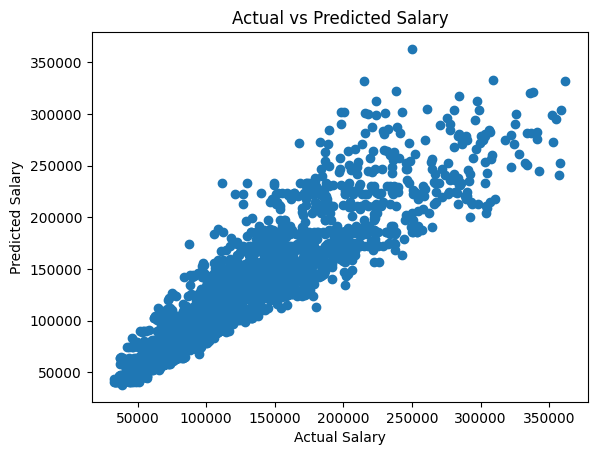

In [64]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

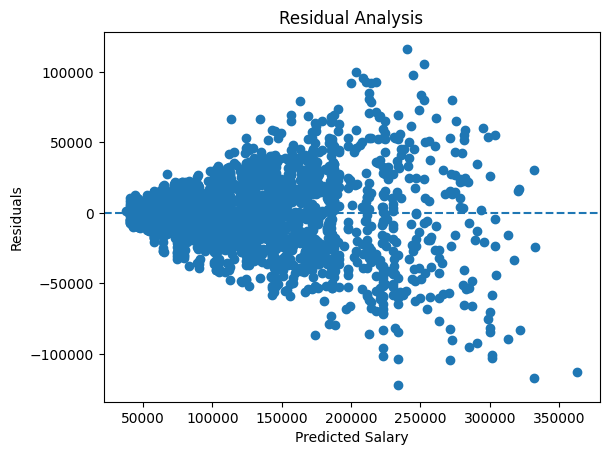

In [65]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()

In [66]:
import joblib

joblib.dump(reg.best_estimator_, "ai_job_salary_model.pkl")


['ai_job_salary_model.pkl']

In [67]:
model = joblib.load("ai_job_salary_model.pkl")

In [68]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Final Model Performance")
print("-----------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

Final Model Performance
-----------------------
MAE : 16683.702328057258
MSE : 563789043.4965378
RMSE: 23744.242323067247
R2  : 0.8454181774377263


In [69]:
import joblib

final_model = reg.best_estimator_

joblib.dump(final_model, "ai_job_salary_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [70]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("feature_selection", SelectKBest(f_regression, k=20)),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

final_pipeline.fit(X_train, y_train)

joblib.dump(
    final_pipeline,
    "ai_job_salary_model_compressed.pkl",
    compress=9
)

['ai_job_salary_model_compressed.pkl']